In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import networkx as nx 
import pandas as pd
import numpy as np 

import seaborn as sns
from tqdm import tqdm

from functions import *
from collections import Counter

FIGURE_DIR = Path("../figures")

In [2]:
import yaml

CONFIG_PATH = Path("../workflow/config.yaml")

with CONFIG_PATH.open("r") as f:
    config = yaml.safe_load(f)

DATA_DIR = Path(config["results_dir"])

In [ ]:
month_idx = pd.date_range(start='08/01/2015', end='12/01/2016', freq='MS', tz='UTC')
month_idx_str = [m.strftime('%Y%m') for m in month_idx]

monthly_network = []

for month in tqdm(month_idx_str):
    network_file = DATA_DIR / f'networks/month={month}/network.gexf'
    txG = nx.read_gexf(network_file)

    # Keep compatibility with older network files that only had value.
    if not nx.get_edge_attributes(txG, 'log_value'):
        log_value = {}
        for edge, value in nx.get_edge_attributes(txG, 'value').items():
            value = float(value)
            if value > 0:
                log_value[edge] = np.log10(value)
        nx.set_edge_attributes(txG, log_value, 'log_value')
    
    monthly_network.append(txG)

 18%|█▊        | 3/17 [00:01<00:07,  1.99it/s]

 59%|█████▉    | 10/17 [00:25<00:35,  5.05s/it]

In [3]:
def count_labeled_nodes(graph, label):
    return sum(1 for _, attrs in graph.nodes(data=True) if attrs.get(label) in (1, '1', True))

network_stats = []

for month, graph in zip(month_idx_str, monthly_network):
    network_stats.append({
        "month": month,
        "date": pd.to_datetime(month, format="%Y%m"),
        "nodes": graph.number_of_nodes(),
        "links": graph.number_of_edges(),
        "density": nx.density(graph),

        # actor groups
        "miners": count_labeled_nodes(graph, "miner"),
        "genesis": count_labeled_nodes(graph, "genesis"),
        "exchanges": count_labeled_nodes(graph, "Exchange"),

        # add these only if these labels exist in your graph
        "token_contracts": count_labeled_nodes(graph, "token_contract"),
        "ico": count_labeled_nodes(graph, "ico"),
    })

network_stats_df = pd.DataFrame(network_stats).sort_values("date").reset_index(drop=True)

network_stats_df.head()

,month,date,nodes,links,density,miners,genesis,exchanges,token_contracts,ico
0,201508,2015-08-01,10575,16468,0.000147,1180,1520,6,0,0
1,201509,2015-09-01,6337,11267,0.000281,775,407,6,0,0
2,201510,2015-10-01,7454,11407,0.000205,562,327,6,0,0
3,201511,2015-11-01,8518,12439,0.000171,485,238,6,0,0
4,201512,2015-12-01,7300,12592,0.000236,431,242,6,0,0


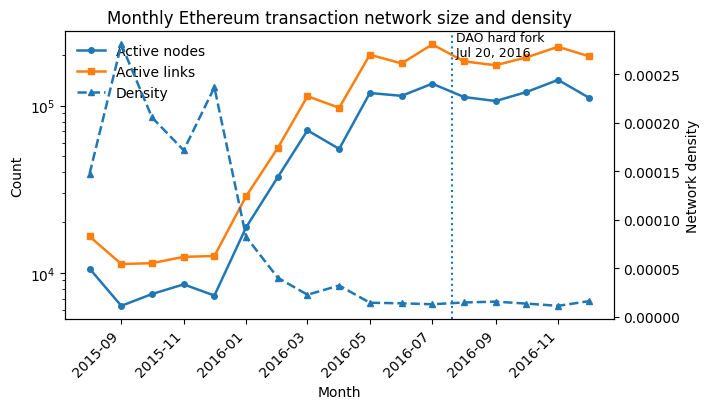

In [4]:
import matplotlib.dates as mdates


fork_date = pd.Timestamp("2016-07-20")
event_month = pd.Timestamp("2016-07-01")

fig, ax1 = plt.subplots(figsize=(7.2, 4.2))

# Left axis: counts
ax1.plot(
    network_stats_df["date"],
    network_stats_df["nodes"],
    marker="o",
    linewidth=1.8,
    markersize=4,
    label="Active nodes"
)

ax1.plot(
    network_stats_df["date"],
    network_stats_df["links"],
    marker="s",
    linewidth=1.8,
    markersize=4,
    label="Active links"
)

ax1.set_ylabel("Count")
ax1.set_yscale("log")
ax1.tick_params(axis="y")

# Right axis: density
ax2 = ax1.twinx()

ax2.plot(
    network_stats_df["date"],
    network_stats_df["density"],
    marker="^",
    linewidth=1.8,
    markersize=4,
    linestyle="--",
    label="Density"
)

ax2.set_ylabel("Network density")
ax2.tick_params(axis="y")

# Fork marker
ax1.axvline(
    fork_date,
    linestyle=":",
    linewidth=1.5
)

ax1.text(
    fork_date,
    ax1.get_ylim()[1],
    " DAO hard fork\n Jul 20, 2016",
    ha="left",
    va="top",
    fontsize=9
)

# X-axis formatting
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    frameon=False,
    loc="upper left"
)

ax1.set_title("Monthly Ethereum transaction network size and density")
ax1.set_xlabel("Month")

fig.tight_layout()
plt.show()

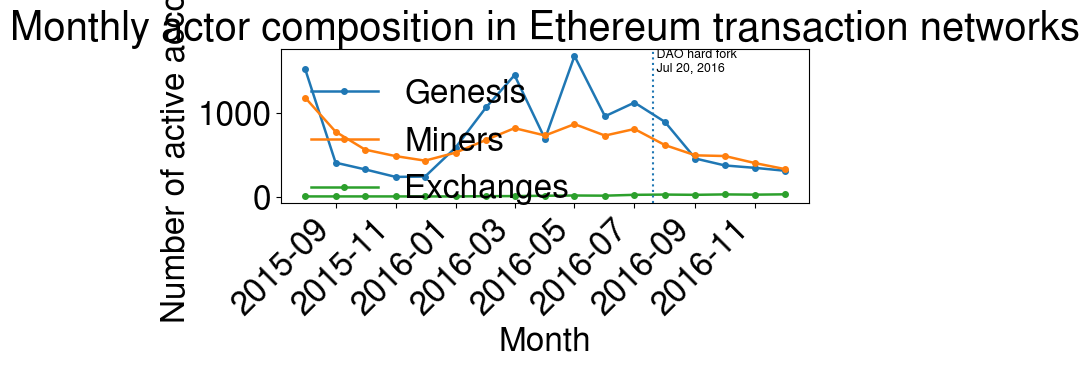

In [ ]:
# ------------------------------------------------------------
# Plot 2A. Monthly actor composition: counts
# ------------------------------------------------------------


fig, ax = plt.subplots(figsize=(7.2, 4.2))

actor_cols = [
    "genesis",
    "miners",
    "exchanges",
    "token_contracts",
    "ico",
]

# Keep only columns that exist and have at least one non-zero value
actor_cols = [
    col for col in actor_cols
    if col in network_stats_df.columns and network_stats_df[col].sum() > 0
]


for col in actor_cols:
    ax.plot(
        network_stats_df["date"],
        network_stats_df[col],
        marker="o",
        linewidth=1.8,
        markersize=4,
        label=col.replace("_", " ").title()
    )

ax.axvline(
    fork_date,
    linestyle=":",
    linewidth=1.5
)

ax.text(
    fork_date,
    ax.get_ylim()[1],
    " DAO hard fork\n Jul 20, 2016",
    ha="left",
    va="top",
    fontsize=9
)

ax.set_xlabel("Month")
ax.set_ylabel("Number of active accounts")
ax.set_title("Monthly actor composition in Ethereum transaction networks")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

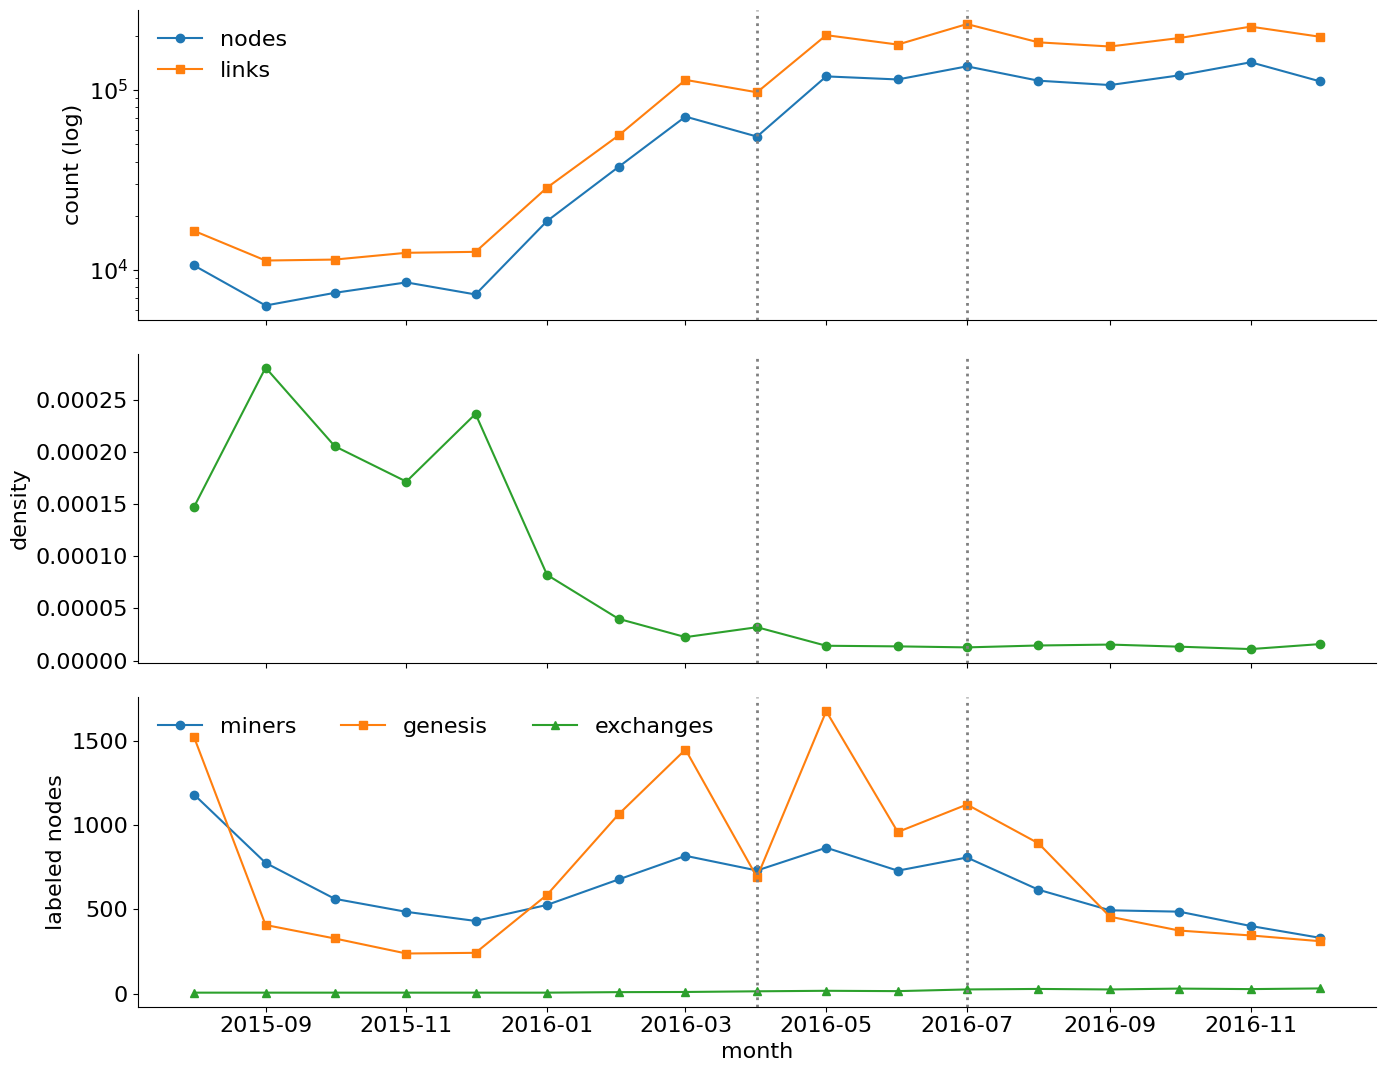

In [14]:
plt.rcParams['figure.figsize'] = (14, 11)
plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(3, 1, sharex=True)

axes[0].plot(network_stats_df['date'], network_stats_df['nodes'], marker='o', label='nodes')
axes[0].plot(network_stats_df['date'], network_stats_df['links'], marker='s', label='links')
axes[0].set_yscale('log')
axes[0].set_ylabel('count (log)')
axes[0].legend(frameon=False)

axes[1].plot(network_stats_df['date'], network_stats_df['density'], marker='o', color='tab:green')
axes[1].set_ylabel('density')

for column, marker in [('miners', 'o'), ('genesis', 's'), ('exchanges', '^')]:
    axes[2].plot(network_stats_df['date'], network_stats_df[column], marker=marker, label=column)
axes[2].set_ylabel('labeled nodes')
axes[2].set_xlabel('month')
axes[2].legend(frameon=False, ncol=3)

for ax in axes:
    ax.axvline(pd.Timestamp('2016-04-01'), color='gray', linestyle=':', linewidth=2)
    ax.axvline(pd.Timestamp('2016-07-01'), color='gray', linestyle=':', linewidth=2)
    ax.spines[['right', 'top']].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / 'network_statistics_timeseries.eps', format='eps', bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'network_statistics_timeseries.pdf', bbox_inches='tight')


### power-law fitting (log-log plot)

In [4]:
import matplotlib as mpl

colorlist = []

for i in range(3):
    color = mpl.cm.get_cmap('Set2')(i)
    color = np.array(color).reshape(1,-1)
    colorlist.append(color)

/tmp/ipykernel_456789/671957915.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color = mpl.cm.get_cmap('Set2')(i)


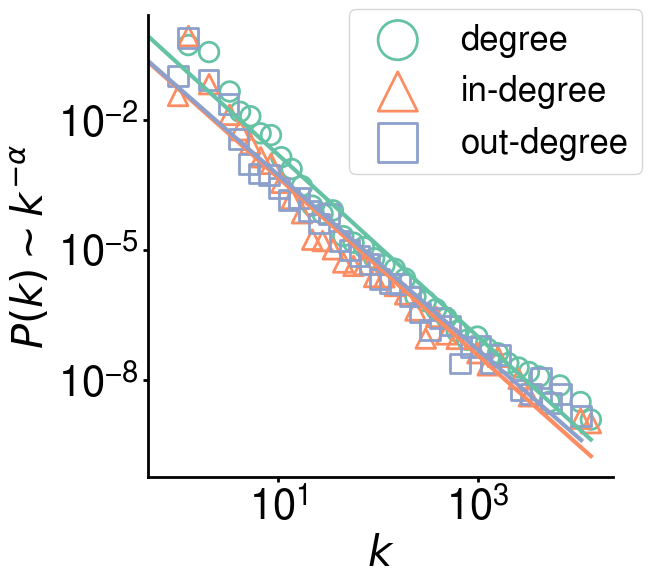

In [16]:
plt.rcParams['figure.figsize'] = (6,6)
plt.rcParams['font.size'] = 30
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Nimbus Sans"]
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['lines.markersize'] = 10
 
fig, ax = plt.subplots()

degreereg = power_law_fitting(txG.degree(), 1, ax, colorlist[0], "o", "degree")
indegreereg = power_law_fitting(txG.in_degree(), 1, ax, colorlist[1], "^", "in-degree")
outdegreereg = power_law_fitting(txG.out_degree(), 1, ax, colorlist[2], "s", 'out-degree')

plt.xlabel(r'$k$')
plt.ylabel(r'$P(k) \sim k^{-\alpha}$')
plt.legend(markerscale=2, fontsize=25, bbox_to_anchor=(1.1, 1.05))
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
ax.tick_params(width=2)
plt.savefig('../figures/degree_distribution_amonth.pdf', dpi=200, bbox_inches='tight')

In [9]:
import statsmodels.api as sm

def power_law_fitting(degree_by_node, x_min=1,
                      ax=plt.subplot, color='k', marker='o', label='none',
                      visualize=True):
    frequency = [ d for node, d in degree_by_node]
    min_ = np.log10(x_min)
    max_ = np.log10(max(frequency)+1) + 1

    bins = np.logspace(min_, max_, 50)
    bins_out = np.insert(bins, 0, 0)
    bin_width = bins - bins_out[:-1]
    plot_data = Counter(np.digitize(frequency, bins))

    # logar
    plot_data = sorted(plot_data.items(), key=(lambda x: x[0]))
    x = [bins[k] for k,v in plot_data]
    y = [v/bin_width[k] for k,v in plot_data]
    y = y/sum(y)

    # fitting with stats model
    alpha = 0.20 # 95% confidence interval
    reg = sm.OLS(np.log10(y), sm.add_constant(np.log10(x))).fit()
    conf_interval = reg.conf_int(alpha)

    def power_law(x, a, b):
        return np.power(10,b)*np.power(x, a)
    
    if visualize:
        # ax.scatter(np.log10(x), np.log10(y))
        plt.scatter(x, y, edgecolors=color, marker=marker, label=label, s=200, lw=2,
                    facecolors='none', 
                    )
        draw_x = np.arange(0.5, max(x), 0.1)
        draw_y = power_law(draw_x, reg.params[1], reg.params[0])
        ax.plot(draw_x, draw_y, c=color)

        plt.xscale('log')
        plt.yscale('log')

        plt.xlim(left=0.5)
        ax.spines[['right', 'top']].set_visible(False)

    return reg, conf_interval
    # return reg.coef_[0], reg.intercept_


## Temporal Analysis (exponents)

In [ ]:
power_law_exponent = {}

confidence_interval = np.array([[]])
for month, txG in tqdm(zip(month_idx_str, monthly_network)):

    degreereg = power_law_fitting(txG.degree(), 10, visualize=False)
    indegreereg = power_law_fitting(txG.in_degree(), 10, visualize=False)
    outdegreereg = power_law_fitting(txG.out_degree(), 10, visualize=False)

    # strength: weigthed by value
    # strreg = power_law_fitting(txG.degree(weight="value"), visualize=False)
    # instrreg = power_law_fitting(txG.in_degree(weight="value"), visualize=False)
    # outstrreg = power_law_fitting(txG.out_degree(weight="value"), visualize=False)
    
    # strength: weigthed by log-value
    logstrreg = power_law_fitting(txG.degree(weight="log_value"), 50, visualize=False)
    loginstrreg = power_law_fitting(txG.in_degree(weight="log_value"), 50, visualize=False)
    logoutstrreg = power_law_fitting(txG.out_degree(weight="log_value"), 50, visualize=False)

    columns = ['degree', 'indegree', 'ou']
    power_law_exponent[month] = {'degree': degreereg[0].params[1], 'in-degree': indegreereg[0].params[1], 'out-degree': outdegreereg[0].params[1],
                                #  'strength': strreg.coef_[0], 'in-strength': instrreg.coef_[0], 'out-strength': outstrreg.coef_[0],
                                 'strength': logstrreg[0].params[1], 'in-strength': loginstrreg[0].params[1], 'out-strength': logoutstrreg[0].params[1]
                                 }

    conf_mat = np.concatenate((degreereg[1][1], indegreereg[1][1], outdegreereg[1][1], logstrreg[1][1], loginstrreg[1][1], logoutstrreg[1][1]))

    # confidence_interval = np.vstack([confidence_interval, conf_mat])
    if month == '201508':
        confidence_interval = conf_mat
    else:    
        confidence_interval = np.vstack([confidence_interval, conf_mat])


In [6]:
import matplotlib as mpl

colorlist = []

for i in [9,7,6]:
    color = mpl.cm.get_cmap('GnBu', 10)(i)
    color = np.array(color).reshape(1,-1)
    colorlist.append(color)

for i in [9,7,6]:
    color = mpl.cm.get_cmap('OrRd', 10)(i)
    color = np.array(color).reshape(1,-1)
    colorlist.append(color)


/tmp/ipykernel_456789/3405227273.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color = mpl.cm.get_cmap('GnBu', 10)(i)
/tmp/ipykernel_456789/3405227273.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color = mpl.cm.get_cmap('OrRd', 10)(i)


1
4


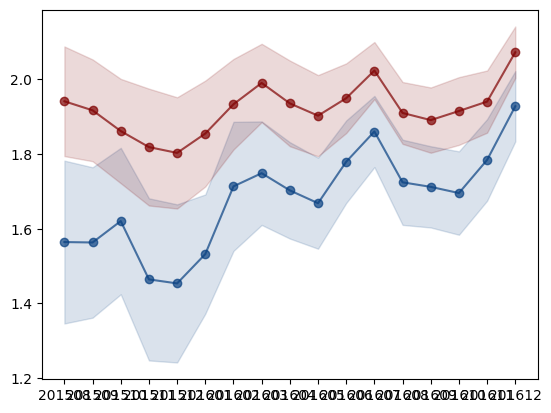

In [12]:
fig, ax = plt.subplots()

df =  pd.DataFrame.from_dict(power_law_exponent, orient='index')
df = df.reset_index().rename(columns={'index':'month'})


cols = df.columns
errors = confidence_interval.T
markers = ['o', '^', 's', 'o', '^', 's']

for i in range(1, 7):
    if i not in [1, 4]:
        continue
    print(i)
    estimate = -df[cols[i]]

    lower = -errors[2*i - 1]
    upper = -errors[2*i - 2]

    ax.plot(
        df['month'],
        estimate,
        marker=markers[i-1],
        label=cols[i],
        c=colorlist[i-1],
        alpha=.7,
    )

    ax.fill_between(
        df['month'],
        lower,
        upper,
        color=colorlist[i-1],
        alpha=.15
    )

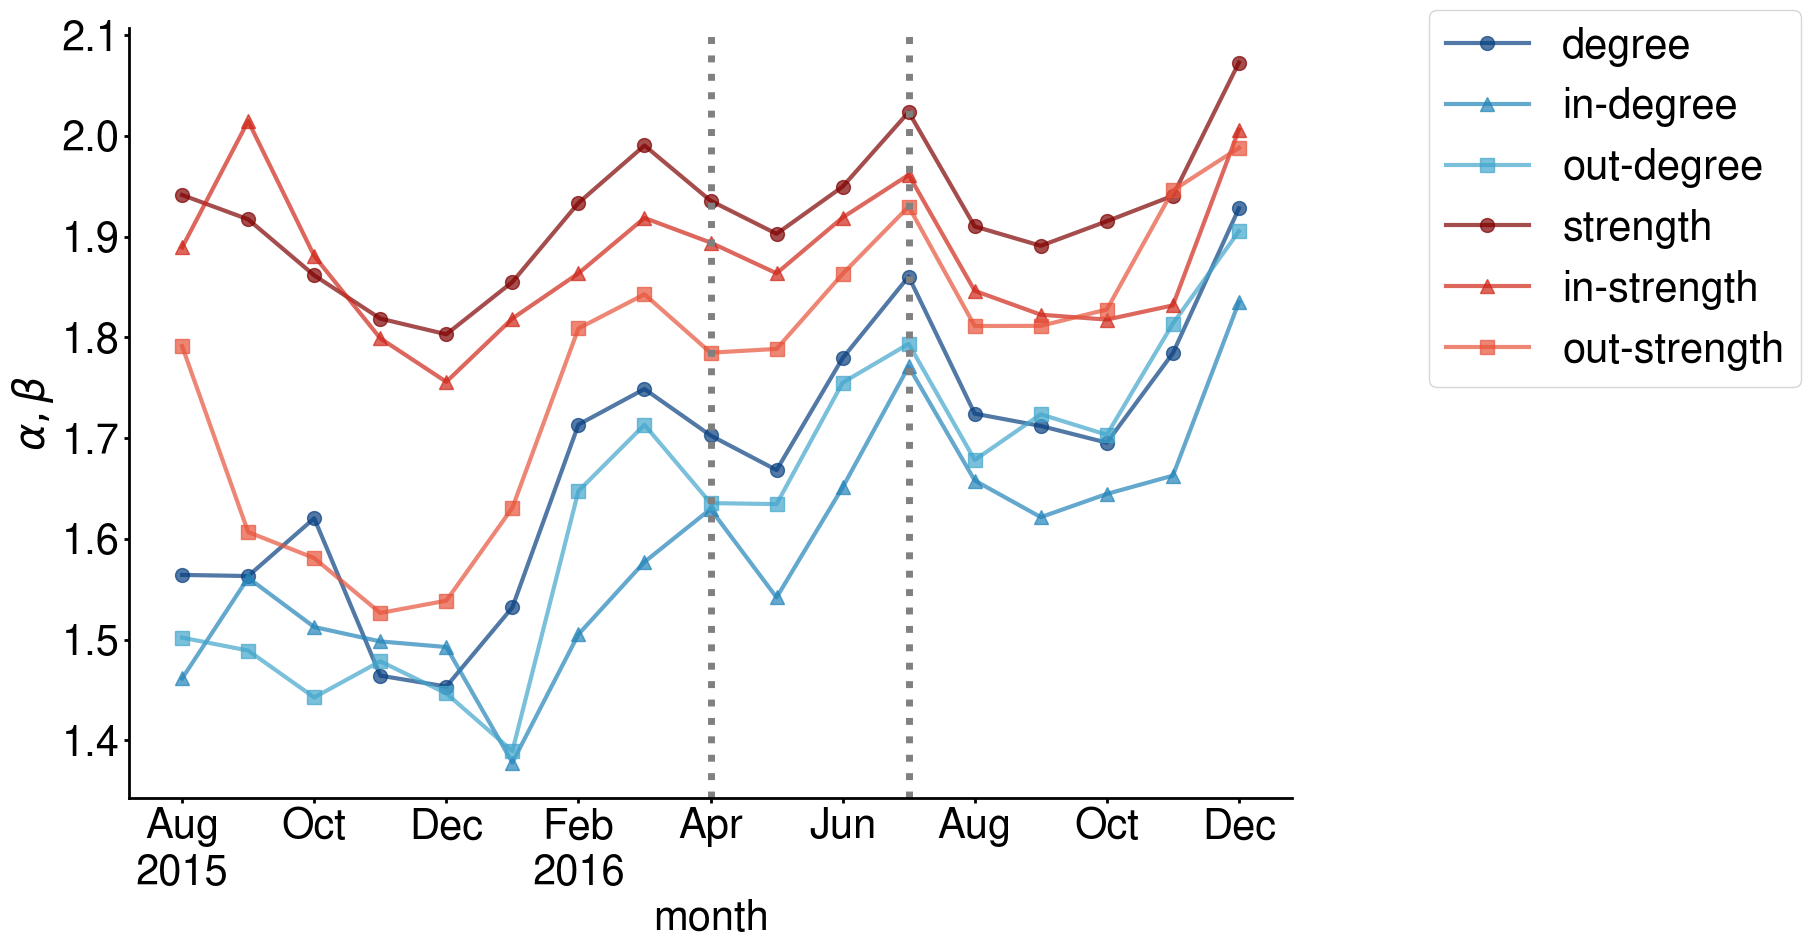

In [20]:
plt.rcParams['figure.figsize'] = (15,10)

df =  pd.DataFrame.from_dict(power_law_exponent, orient='index')
df = df.reset_index().rename(columns={'index':'month'})

fig, ax = plt.subplots()

cols = df.columns
errors = confidence_interval.T
markers = ['o', '^', 's', 'o', '^', 's']

for i in range(1, 7):
        ax.plot(df['month'], -df[cols[i]], marker=markers[i-1], label=cols[i],
                c=colorlist[i-1], alpha=.7,
                )
        # ax.fill_between(df['month'], -errors[2*i-1], -errors[2*i-2], alpha=.3,
        #         )
# meltdf = df.melt(id_vars='month', value_vars=df.columns[1:4])
# sns.lineplot(data=meltdf, x='month', y='value', hue='variable', 
#         #      style='variable', 
#              markers=['o', '^', 'x'], dashes=False,
#              ax=ax)

showmonth = np.array(month_idx)[[0,2,4,6,8,10,12,14,16]]
xticks = np.array(month_idx_str)[[0,2,4,6,8,10,12,14,16]]
ax.axvline(x='201604', color='gray', linestyle=':', linewidth=5)
ax.axvline(x='201607', color='gray', linestyle=':', linewidth=5)

plt.xticks(xticks, 
        [ts.strftime('%b\n%Y') if ts.year != showmonth[idx-1].year
                    else ts.strftime('%b') for idx, ts in enumerate(showmonth)])


plt.ylabel(r'$\alpha, \beta$')
plt.xlabel('month')
plt.legend(bbox_to_anchor=(1.1, 1.05))
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
ax.tick_params(width=2)
plt.savefig('../figures/degree_distribution.pdf', dpi=200, bbox_inches='tight')

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def top_share(values, top_ratio):
    values = np.asarray(values, dtype=float)
    values = values[
        np.isfinite(values)
        & (values > 0)
    ]

    if len(values) == 0:
        return np.nan

    n_top = max(1, int(np.ceil(len(values) * top_ratio)))

    values = np.sort(values)[::-1]

    return values[:n_top].sum() / values.sum()


rows = []

for month, txG in zip(month_idx_str, monthly_network):

    degree_values = [value for _, value in txG.degree()]
    strength_values = [value
        for _, value in txG.degree(
            weight="log_value"
        )
    ]

    degree_top1 = top_share(degree_values, 0.01)
    strength_top1 = top_share(strength_values, 0.01)

    rows.append({
        "month": month,
        "degree_top1": degree_top1,
        "strength_top1": strength_top1,
    })

share_df = pd.DataFrame(rows)

### Publishing Figures

In [38]:
network_stats_df

,month,date,nodes,links,density,miners,genesis,exchanges,token_contracts,ico
0,201508,2015-08-01,10575,16468,0.000147,1180,1520,6,0,0
1,201509,2015-09-01,6337,11267,0.000281,775,407,6,0,0
2,201510,2015-10-01,7454,11407,0.000205,562,327,6,0,0
3,201511,2015-11-01,8518,12439,0.000171,485,238,6,0,0
4,201512,2015-12-01,7300,12592,0.000236,431,242,6,0,0
5,201601,2016-01-01,18678,28650,0.000082,526,586,6,0,0
6,201602,2016-02-01,37332,55807,0.000040,677,1063,9,0,0
7,201603,2016-03-01,71052,113661,0.000023,817,1447,10,0,0
8,201604,2016-04-01,55021,96961,0.000032,730,690,14,0,0
9,201605,2016-05-01,118848,201441,0.000014,865,1674,17,0,0


In [ ]:
import matplotlib as mpl

colorlist = []

for i in range(3):
    color = mpl.cm.get_cmap('Set2')(i)
    color = np.array(color).reshape(1,-1)
    colorlist.append(color)

/tmp/ipykernel_456789/3592369797.py:184: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color = mpl.cm.get_cmap('Set2')(i)


0.05
0.05
0.05


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


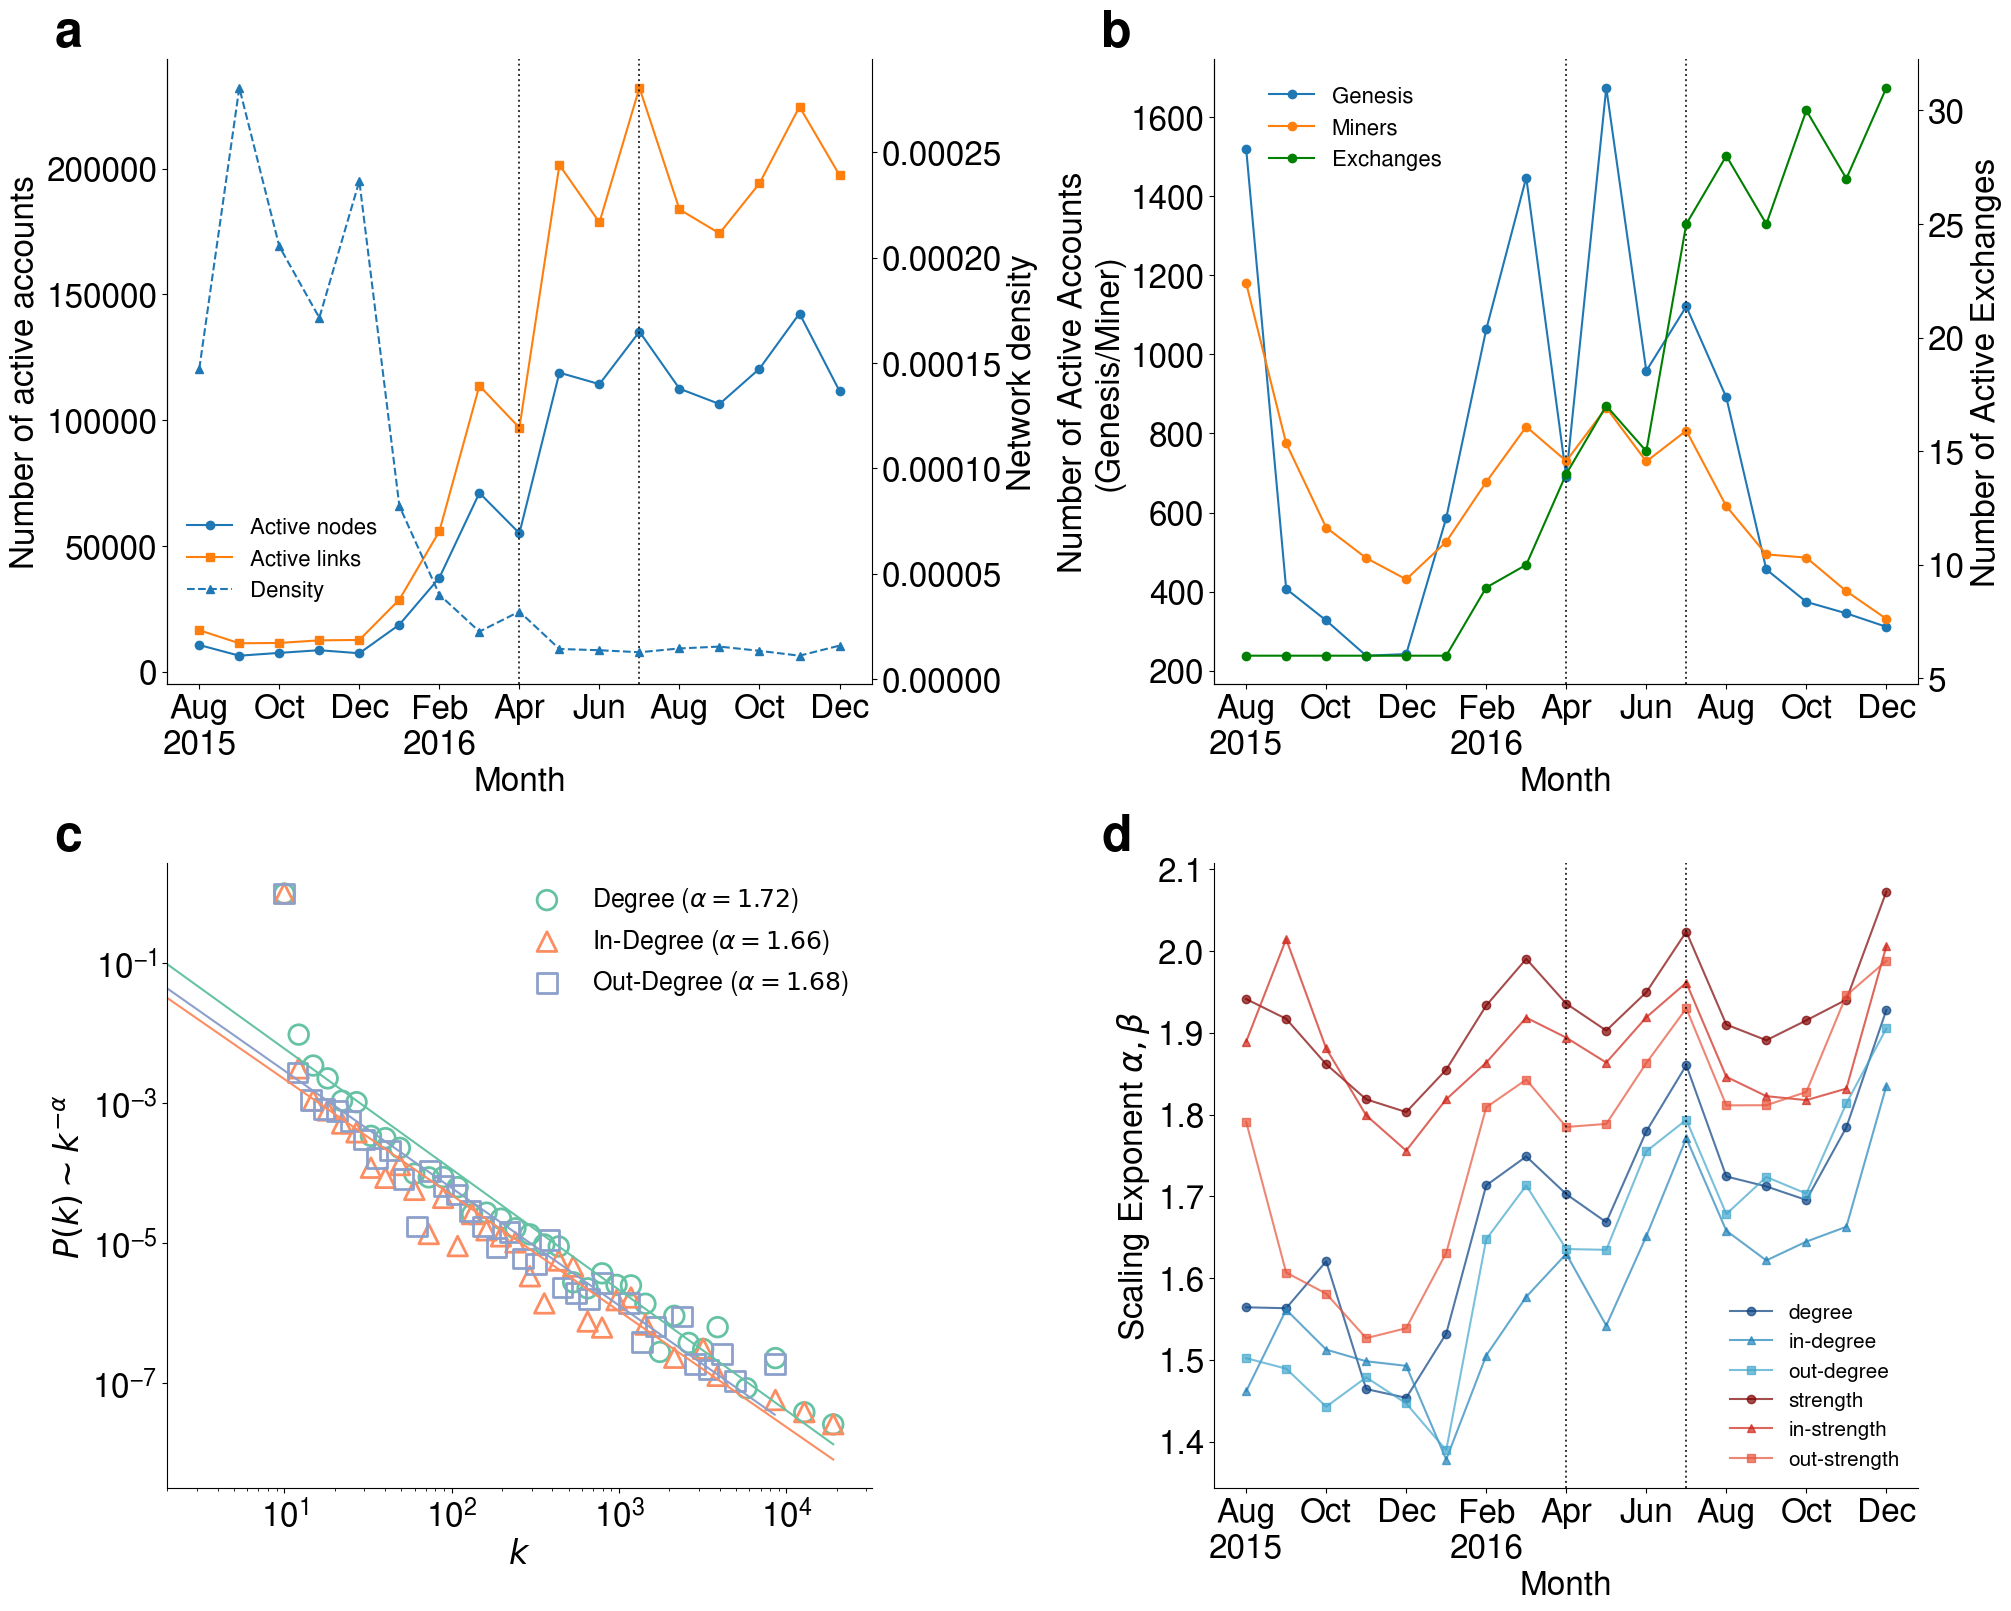

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

plt.rcParams['font.family'] = 'Nimbus Sans'
plt.rcParams['font.size'] = 24

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(20, 16),
    constrained_layout=True
)

ax_a = axes[0, 0]
ax_b = axes[0, 1]
ax_c = axes[1, 0]
ax_d = axes[1, 1]

def add_panel_label(ax, label):
    ax.text(
        -0.16, 1.08,
        label,
        transform=ax.transAxes,
        fontsize=36,
        fontweight="bold",
        va="top",
        ha="left"
    )


def add_DAO_and_fork_line(ax, dao_month, fork_month, text=True):
    ax.axvline(
        dao_month,
        linestyle=":",
        linewidth=1.4,
        color="black",
        alpha=0.8
    )
    ax.axvline(
        fork_month,
        linestyle=":",
        linewidth=1.4,
        color="black",
        alpha=0.8
    )

def format_month_xticks(ax, month_idx, month_idx_str, step=2):
    tick_pos = np.arange(0, len(month_idx_str), step)
    showmonth = np.array(month_idx)[tick_pos]
    xticks = np.array(month_idx_str)[tick_pos]

    tick_labels = []
    prev_year = None

    for ts in showmonth:
        ts = pd.to_datetime(ts)

        if prev_year is None or ts.year != prev_year:
            tick_labels.append(ts.strftime("%b\n%Y"))
        else:
            tick_labels.append(ts.strftime("%b"))

        prev_year = ts.year

    ax.set_xticks(xticks)
    ax.set_xticklabels(tick_labels)

#### ------------------------------------------------------------

add_panel_label(ax_a, "a")

ax_a.plot(
    network_stats_df["month"],
    network_stats_df["nodes"],
    marker="o",
    label="Active nodes"
)

ax_a.plot(
    network_stats_df["month"],
    network_stats_df["links"],
    marker="s",
    label="Active links"
)

ax_a2 = ax_a.twinx()

ax_a2.plot(
    network_stats_df["month"],
    network_stats_df["density"],
    marker="^",
    linestyle="--",
    label="Density"
)

ax_a2.set_ylabel("Network density")
ax_a2.tick_params(axis="y")

add_DAO_and_fork_line(ax_a, '201604', '201607')
format_month_xticks(ax_a, month_idx, month_idx_str, step=2)

ax_a.set_xlabel("Month")
ax_a.set_ylabel("Number of active accounts")

# Combine legends from both axes
lines_1, labels_1 = ax_a.get_legend_handles_labels()
lines_2, labels_2 = ax_a2.get_legend_handles_labels()
ax_a.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    frameon=False,
    loc="lower left",
    bbox_to_anchor=(0, 0.1),
    fontsize=16,
)

# ------------------------------------------------------------

add_panel_label(ax_b, "b")

actor_cols = [
    "genesis",
    "miners",
    "exchanges",
    "token_contracts",
    "ico",
]

# Keep only columns that exist and have at least one non-zero value
actor_cols = [
    col for col in actor_cols
    if col in network_stats_df.columns and network_stats_df[col].sum() > 0
]

ax_b2 = ax_b.twinx()

for col in actor_cols:
    if col == 'exchanges':
        ax_b2.plot(
            network_stats_df["month"],
            network_stats_df[col],
            marker="o",
            color='green',
            label=col.replace("_", " ").title()
        )
    else:
        ax_b.plot(
            network_stats_df["month"],
            network_stats_df[col],
            marker="o",
            label=col.replace("_", " ").title()
        )

add_DAO_and_fork_line(ax_b, '201604', '201607')
format_month_xticks(ax_b, month_idx, month_idx_str, step=2)

ax_b.set_xlabel("Month")
ax_b.set_ylabel("Number of Active Accounts\n(Genesis/Miner)")
ax_b2.set_ylabel("Number of Active Exchanges")

# Combine legends from both axes
lines_1, labels_1 = ax_b.get_legend_handles_labels()
lines_2, labels_2 = ax_b2.get_legend_handles_labels()
ax_b.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.05, 0.99),
    fontsize=16
)

# ------------------------------------------------------------
# Fig. 2c. Degree distribution before and after fork
# ------------------------------------------------------------

add_panel_label(ax_c, "c")
plt.sca(ax_c)

colors = []

for i in range(3):
    color = mpl.cm.get_cmap('Set2')(i)
    color = np.array(color).reshape(1,-1)
    colors.append(color)

reg = power_law_fitting(monthly_network[12].degree(), 10, ax_c, colors[0], "o", "Degree")
inreg = power_law_fitting(monthly_network[12].in_degree(), 10, ax_c, colors[1], "^", "In-Degree")
outreg = power_law_fitting(monthly_network[12].out_degree(), 10, ax_c, colors[2], "s", "Out-Degree")

ax_c.set_xlim(2)
ax_c.set_xlabel(r'$k$')
ax_c.set_ylabel(r'$P(k) \sim k^{-\alpha}$')
ax_c.legend(markerscale=1, fontsize=18, frameon=False)

# ------------------------------------------------------------
# Fig. 2d. Scaling exponent temporal change
# ------------------------------------------------------------

add_panel_label(ax_d, "d")

df =  pd.DataFrame.from_dict(power_law_exponent, orient='index')
df = df.reset_index().rename(columns={'index':'month'})

cols = df.columns
errors = confidence_interval.T
markers = ['o', '^', 's', 'o', '^', 's']

for i in range(1, 7):
    ax_d.plot(df['month'], -df[cols[i]], marker=markers[i-1], label=cols[i],
            c=colorlist[i-1], alpha=.7,
    )

add_DAO_and_fork_line(ax_d, '201604', '201607')
format_month_xticks(ax_d, month_idx, month_idx_str, step=2)

ax_d.set_xlabel("Month")
ax_d.set_ylabel(r"Scaling Exponent $\alpha, \beta$")
ax_d.legend(frameon=False, fontsize=15)


# ------------------------------------------------------------
# Fig. 2d. Top 1% concentration over time
# ------------------------------------------------------------

# add_panel_label(ax_d, "d")

# ax_d.plot(
#     top1_df["month"],
#     top1_df["degree_top1_share"] * 100,
#     marker="o",
#     label="Degree"
# )

# ax_d.plot(
#     top1_df["month"],
#     top1_df["strength_top1_share"] * 100,
#     marker="s",
#     label="Strength"
# )

# add_DAO_and_fork_line(ax_d, '201604', '201607')
# format_month_xticks(ax_d, month_idx, month_idx_str, step=2)

# ax_d.set_ylabel(
#     "Share Degree or Strength\n" \
#     "for Top 1% Accounts (%)"
# )

# ax_d.set_xlabel("Month")

# ax_d.legend(
#     frameon=False,
#     loc="best",
#     fontsize=18
# )

# ------------------------------------------------------------
# Optional global formatting
# ------------------------------------------------------------

for ax in [ax_a, ax_a2, ax_b, ax_b2, ax_c, ax_d]:
    ax.spines["top"].set_visible(False)
    if ax not in [ax_a2, ax_b2]:  # Keep right spine for ax_a2 (density axis)
        ax.spines["right"].set_visible(False)


fig.savefig("figure2_network_size_density.png", dpi=300, bbox_inches="tight")
fig.savefig("figure2_network_size_density.eps", bbox_inches="tight")
plt.show()

In [22]:
inreg[0].params[1]

-1.6578861853904285

In [20]:
reg[0].params

array([-0.49666896, -1.72425876])

In [21]:
inreg[0].model.exog_names

['const', 'x1']